# TDA Pipeline Validation Gates

**Purpose:** validate the persistent-homology pipeline on signals with KNOWN
topology BEFORE interpreting real Weather / ETTh results. This is the
ground-truth-first rule (lesson from the corr_dim and Rosenstein failures:
every estimator gets a positive control before touching unknown data).

**Run this in the same environment as `tda_persistent_homology_notebook`**
(same ripser version), BEFORE the real-data run. Runtime: ~2-4 min on CPU.

**Gate logic (criteria fixed a priori, before seeing real Weather):**

| Gate | Signal | Known topology | Expected H1 signature | Type |
|---|---|---|---|---|
| A | Pure sine (period 100) | circle, b1=1 | 1 dominant loop | hard |
| B | Quasiperiodic torus (golden ratio) | 2-torus, b1=2 | 2 loops above noise floor | soft |
| C | Lorenz (x,y,z channels) | strange attractor | dominant loop(s), matches pilot | hard |
| D | White noise | no loops | many short-lived features, no gap | hard |
| E | AR(1), phi=0.95 | smooth, no loops | no dominant gap | hard |
| F | Subsample-seed stability (sine) | - | max_pers CV < 20% across seeds | hard |

**Decision rule:** all hard gates pass -> run the real-data notebook
unchanged. Any hard gate fails -> fix before real data (playbooks in the
last cell). Gate B soft-fails -> proceed, but flag that secondary loop
structure may be under-resolved when interpreting Weather.

Pass thresholds (3x dominance, 3x noise floor, CV<0.2) are heuristics
chosen a priori; they are documented here precisely so they cannot be
adjusted after seeing the real-data results.

In [2]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

from ripser import ripser

## Pipeline functions — VERBATIM copy from `tda_persistent_homology_notebook`

Do not edit here. Any change to these functions must be mirrored in the
real-data notebook (and vice versa) before gate results and real-data
results are compared — validating the exact pipeline is the whole point.

In [3]:
def mutual_information_tau(x, max_lag=100, n_bins=16):
    """
    Estimate optimal delay tau as the first local minimum of mutual information.
    MI captures nonlinear dependence; autocorrelation only captures linear
    structure, which is insufficient for chaotic/nonlinear signals.
    """
    mis = []
    for lag in range(1, max_lag + 1):
        x1, x2 = x[:-lag], x[lag:]
        hist2d, _, _ = np.histogram2d(x1, x2, bins=n_bins)
        hist2d = hist2d / hist2d.sum()
        px = hist2d.sum(axis=1, keepdims=True)
        py = hist2d.sum(axis=0, keepdims=True)
        outer = px @ py
        mask = (hist2d > 0) & (outer > 0)
        mi = np.sum(hist2d[mask] * np.log(hist2d[mask] / outer[mask]))
        mis.append(mi)
    mis = np.array(mis)
    for i in range(1, len(mis) - 1):
        if mis[i] < mis[i-1] and mis[i] < mis[i+1]:
            return i + 1
    return 1  # fallback if no local minimum found in range

def delay_embed(x, d, tau):
    """Takens delay embedding: x(t), x(t+tau), ..., x(t+(d-1)*tau)."""
    N = len(x) - (d - 1) * tau
    if N <= 0:
        raise ValueError(f"Signal too short for d={d}, tau={tau}: len={len(x)}")
    return np.stack([x[i*tau : i*tau + N] for i in range(d)], axis=1)

def subsample_cloud(cloud, n=800, seed=42):
    """Random subsample to bound O(n^2) Vietoris-Rips memory cost."""
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(cloud), size=min(n, len(cloud)), replace=False)
    return cloud[idx]

def compute_h1_persistence(cloud):
    """Run ripser, return finite H1 (birth, death) pairs."""
    result = ripser(cloud, maxdim=1)
    h1 = result['dgms'][1]
    h1 = h1[np.isfinite(h1[:, 1])] if len(h1) > 0 else h1
    return h1

def persistence_stats(h1_pairs):
    """Summary statistics from an H1 persistence diagram."""
    if len(h1_pairs) == 0:
        return {'max_pers': 0.0, 'total_pers': 0.0, 'n_features': 0}
    pers = h1_pairs[:, 1] - h1_pairs[:, 0]
    return {'max_pers': float(pers.max()), 'total_pers': float(pers.sum()), 'n_features': len(pers)}

## Lorenz simulator — VERBATIM copy from the real-data notebook (Cell 3)

In [4]:
def simulate_lorenz(n=5000, dt=0.01, sigma=10, rho=28, beta=8/3):
    """RK4 integration of the Lorenz system."""
    x, y, z = 0.1, 0.0, 0.0
    xs, ys, zs = [x], [y], [z]
    for _ in range(n - 1):
        k1x = sigma * (y - x)
        k1y = x * (rho - z) - y
        k1z = x * y - beta * z
        k2x = sigma * ((y + dt/2*k1y) - (x + dt/2*k1x))
        k2y = (x + dt/2*k1x) * (rho - (z + dt/2*k1z)) - (y + dt/2*k1y)
        k2z = (x + dt/2*k1x) * (y + dt/2*k1y) - beta * (z + dt/2*k1z)
        k3x = sigma * ((y + dt/2*k2y) - (x + dt/2*k2x))
        k3y = (x + dt/2*k2x) * (rho - (z + dt/2*k2z)) - (y + dt/2*k2y)
        k3z = (x + dt/2*k2x) * (y + dt/2*k2y) - beta * (z + dt/2*k2z)
        k4x = sigma * ((y + dt*k3y) - (x + dt*k3x))
        k4y = (x + dt*k3x) * (rho - (z + dt*k3z)) - (y + dt*k3y)
        k4z = (x + dt*k3x) * (y + dt*k3y) - beta * (z + dt*k3z)
        x += dt/6*(k1x+2*k2x+2*k3x+k4x)
        y += dt/6*(k1y+2*k2y+2*k3y+k4y)
        z += dt/6*(k1z+2*k2z+2*k3z+k4z)
        xs.append(x); ys.append(y); zs.append(z)
    return np.array([xs, ys, zs]).T

## Control signals

All controls have length 3000, matching `N_POINTS_TIMESERIES` in the
real-data run, and go through the pipeline with the SAME parameters
(d=3, max_tau=80, n_points=800).

In [5]:
N_CONTROL = 3000
t = np.arange(N_CONTROL)
rng_master = np.random.default_rng(42)

# Gate A: pure sine, period 100 samples (30 full cycles).
# Delay embedding of a sinusoid is a closed planar curve: exactly one loop.
sig_sine = np.sin(2 * np.pi * t / 100.0)

# Gate B: quasiperiodic sum, incommensurate frequency ratio (golden ratio).
# The orbit fills a 2-torus: two independent loop classes (b1 = 2).
GOLDEN = (1 + np.sqrt(5)) / 2
sig_torus = np.sin(2 * np.pi * t / 100.0) + 0.8 * np.sin(2 * np.pi * t * GOLDEN / 100.0)

# Gate D: white noise. Embedding is an isotropic blob: no persistent loops,
# only many short-lived features. Also serves as the NOISE FLOOR reference
# for the other gates.
sig_noise = rng_master.standard_normal(N_CONTROL)

# Gate E: AR(1) with phi=0.95. Smooth and strongly autocorrelated but
# loop-free. The key over-reading test: Weather channels are smooth and
# autocorrelated, so if the pipeline hallucinates loops here, it will
# hallucinate them on Weather.
phi = 0.95
eps = rng_master.standard_normal(N_CONTROL)
sig_ar1 = np.empty(N_CONTROL)
sig_ar1[0] = eps[0]
for i in range(1, N_CONTROL):
    sig_ar1[i] = phi * sig_ar1[i-1] + eps[i]

# Gate C: Lorenz, 3 channels, transient discarded — identical to the
# real-data notebook's reference dataset.
lorenz_ctrl = simulate_lorenz(n=5000)[500:3500]

print(f"sine {sig_sine.shape}, torus {sig_torus.shape}, "
      f"noise {sig_noise.shape}, ar1 {sig_ar1.shape}, lorenz {lorenz_ctrl.shape}")

sine (3000,), torus (3000,), noise (3000,), ar1 (3000,), lorenz (3000, 3)


## Gate-only orchestration wrapper

Calls the verbatim primitives in the same order and with the same
parameters as `analyse_channel()` in the real-data notebook. Two
additions needed by the gates: it exposes the subsample seed (Gate F)
and returns the full sorted list of H1 lifetimes (dominance-gap
criteria need top1/top2/top3, which `persistence_stats` does not keep).

In [6]:
def gate_analyse(x, d=3, max_tau=80, n_points=800, seed=42, label=""):
    x = (x - x.mean()) / (x.std() + 1e-8)
    tau = mutual_information_tau(x, max_lag=max_tau)
    cloud = delay_embed(x, d=d, tau=tau)
    cloud_s = subsample_cloud(cloud, n=n_points, seed=seed)
    h1 = compute_h1_persistence(cloud_s)
    stats = persistence_stats(h1)
    lifetimes = np.sort(h1[:, 1] - h1[:, 0])[::-1] if len(h1) > 0 else np.array([])
    top = lambda k: float(lifetimes[k]) if len(lifetimes) > k else 0.0
    return {
        'label': label, 'tau': tau, 'n_features': stats['n_features'],
        'max_pers': stats['max_pers'], 'total_pers': stats['total_pers'],
        'top1': top(0), 'top2': top(1), 'top3': top(2),
        'lifetimes': lifetimes, 'cloud': cloud_s,
    }

## Run all controls through the pipeline

In [7]:
results = {}
results['sine']        = gate_analyse(sig_sine,  label='sine')
results['torus']       = gate_analyse(sig_torus, label='torus')
results['white_noise'] = gate_analyse(sig_noise, label='white_noise')
results['ar1']         = gate_analyse(sig_ar1,   label='ar1_phi0.95')

lorenz_ch = []
for ch, name in enumerate(['x', 'y', 'z']):
    r = gate_analyse(lorenz_ctrl[:, ch], label=f'lorenz_{name}')
    lorenz_ch.append(r)
    results[f'lorenz_{name}'] = r

for k, r in results.items():
    print(f"{k:>14}: tau={r['tau']:3d}  n_H1={r['n_features']:4d}  "
          f"top1={r['top1']:.4f}  top2={r['top2']:.4f}  top3={r['top3']:.4f}  "
          f"total={r['total_pers']:.4f}")

          sine: tau=  5  n_H1=  13  top1=1.0950  top2=0.0077  top3=0.0052  total=1.1192
         torus: tau= 20  n_H1= 249  top1=0.4761  top2=0.3930  top3=0.3718  total=19.1885
   white_noise: tau=  2  n_H1= 407  top1=0.4190  top2=0.4163  top3=0.3847  total=31.4625
           ar1: tau= 29  n_H1= 368  top1=0.4256  top2=0.3903  top3=0.3633  total=27.9327
      lorenz_x: tau= 17  n_H1= 196  top1=1.0834  top2=0.4024  top3=0.2462  total=8.2579
      lorenz_y: tau= 16  n_H1= 186  top1=1.0648  top2=0.4756  top3=0.3487  total=8.8803
      lorenz_z: tau= 16  n_H1= 199  top1=0.6153  top2=0.4569  top3=0.4475  total=10.9099


## Gate F — subsample-seed stability (on the sine control)

`subsample_cloud` uses a fixed seed in the real-data run; this checks the
headline statistic is not an artifact of which 800 points were kept.

In [8]:
SEEDS = [42, 123, 777]
seed_mp = [gate_analyse(sig_sine, seed=s, label=f'sine_seed{s}')['max_pers'] for s in SEEDS]
seed_cv = float(np.std(seed_mp) / (np.mean(seed_mp) + 1e-12))
print(f"sine max_pers across seeds {SEEDS}: "
      f"{[f'{v:.4f}' for v in seed_mp]}  ->  CV = {seed_cv:.3f}")

sine max_pers across seeds [42, 123, 777]: ['1.0950', '1.0950', '1.0950']  ->  CV = 0.000


## Automated gate verdicts

All thresholds below were fixed before running (see header). `floor` is
the white-noise top-1 lifetime — the empirical noise floor of this exact
pipeline configuration.

In [9]:
EPS = 1e-12
floor = max(results['white_noise']['top1'], EPS)

def ratio12(r):
    return r['top1'] / max(r['top2'], EPS)

gates = []

r = results['sine']
gates.append({
    'gate': 'A_sine', 'type': 'hard',
    'criterion': 'top1/top2 >= 3 AND top1 >= 3*floor',
    'observed': f"top1/top2={ratio12(r):.2f}, top1/floor={r['top1']/floor:.2f}, tau={r['tau']}",
    'pass': bool(ratio12(r) >= 3 and r['top1'] >= 3 * floor),
})

r = results['torus']
gates.append({
    'gate': 'B_torus', 'type': 'soft',
    'criterion': 'top2 >= 2*floor (two loops above noise floor)',
    'observed': f"top1/floor={r['top1']/floor:.2f}, top2/floor={r['top2']/floor:.2f}, tau={r['tau']}",
    'pass': bool(r['top2'] >= 2 * floor),
})

med_lorenz = float(np.median([c['max_pers'] for c in lorenz_ch]))
best_lorenz = float(np.max([c['max_pers'] for c in lorenz_ch]))
gates.append({
    'gate': 'C_lorenz', 'type': 'hard',
    'criterion': 'median(max_pers over x,y,z) >= 2*floor AND best channel >= 3*floor',
    'observed': f"median/floor={med_lorenz/floor:.2f}, best/floor={best_lorenz/floor:.2f}",
    'pass': bool(med_lorenz >= 2 * floor and best_lorenz >= 3 * floor),
})

r = results['white_noise']
gates.append({
    'gate': 'D_white_noise', 'type': 'hard',
    'criterion': 'n_features >= 3 AND top1/top2 < 2 (no dominant loop)',
    'observed': f"n={r['n_features']}, top1/top2={ratio12(r):.2f}",
    'pass': bool(r['n_features'] >= 3 and ratio12(r) < 2),
})

r = results['ar1']
gates.append({
    'gate': 'E_ar1', 'type': 'hard',
    'criterion': '(top1/top2 < 2) OR (top1 < 2*floor)',
    'observed': f"top1/top2={ratio12(r):.2f}, top1/floor={r['top1']/floor:.2f}",
    'pass': bool(ratio12(r) < 2 or r['top1'] < 2 * floor),
})

gates.append({
    'gate': 'F_seed_stability', 'type': 'hard',
    'criterion': 'CV(max_pers over 3 subsample seeds) < 0.20',
    'observed': f"CV={seed_cv:.3f}",
    'pass': bool(seed_cv < 0.20),
})

df_gates = pd.DataFrame(gates)
print(df_gates[['gate', 'type', 'criterion', 'observed', 'pass']].to_string(index=False))

hard_fail = [g['gate'] for g in gates if g['type'] == 'hard' and not g['pass']]
soft_fail = [g['gate'] for g in gates if g['type'] == 'soft' and not g['pass']]

print()
if not hard_fail:
    print("VERDICT: ALL HARD GATES PASSED -> proceed to the real-data notebook unchanged.")
    if soft_fail:
        print(f"  (soft-fail on {soft_fail}: secondary loop structure may be "
              f"under-resolved — carry this caveat into the Weather interpretation.)")
else:
    print(f"VERDICT: HARD GATE FAILURE on {hard_fail} -> DO NOT run real data yet. "
          f"See failure playbooks in the last cell.")

            gate type                                                          criterion                                 observed  pass
          A_sine hard                                 top1/top2 >= 3 AND top1 >= 3*floor top1/top2=141.89, top1/floor=2.61, tau=5 False
         B_torus soft                      top2 >= 2*floor (two loops above noise floor) top1/floor=1.14, top2/floor=0.94, tau=20 False
        C_lorenz hard median(max_pers over x,y,z) >= 2*floor AND best channel >= 3*floor       median/floor=2.54, best/floor=2.59 False
   D_white_noise hard               n_features >= 3 AND top1/top2 < 2 (no dominant loop)                    n=407, top1/top2=1.01  True
           E_ar1 hard                                (top1/top2 < 2) OR (top1 < 2*floor)          top1/top2=1.09, top1/floor=1.02  True
F_seed_stability hard                         CV(max_pers over 3 subsample seeds) < 0.20                                 CV=0.000  True

VERDICT: HARD GATE FAILURE on ['A_sine', 'C_lor

In [10]:
rows = []
for k, r in results.items():
    rows.append({'signal': k, 'tau': r['tau'], 'n_H1_features': r['n_features'],
                 'top1': round(r['top1'], 5), 'top2': round(r['top2'], 5),
                 'top3': round(r['top3'], 5), 'max_pers': round(r['max_pers'], 5),
                 'total_pers': round(r['total_pers'], 5)})
df_ctrl = pd.DataFrame(rows)
df_ctrl.to_csv('tda_gate_controls.csv', index=False)
df_gates.drop(columns=[]).to_csv('tda_gate_verdicts.csv', index=False)
print("Saved tda_gate_controls.csv and tda_gate_verdicts.csv")

Saved tda_gate_controls.csv and tda_gate_verdicts.csv


## Visual sanity check

Left-to-right: sine, torus, white noise, AR(1), Lorenz-x.
Top row: first two embedding coordinates (should look like: ring, torus
projection, blob, elongated blob, butterfly-ish projection).
Bottom row: top-10 H1 lifetimes (should look like: one tall bar; two
tall-ish bars; flat rubble; flat rubble; tall bar(s) over rubble).

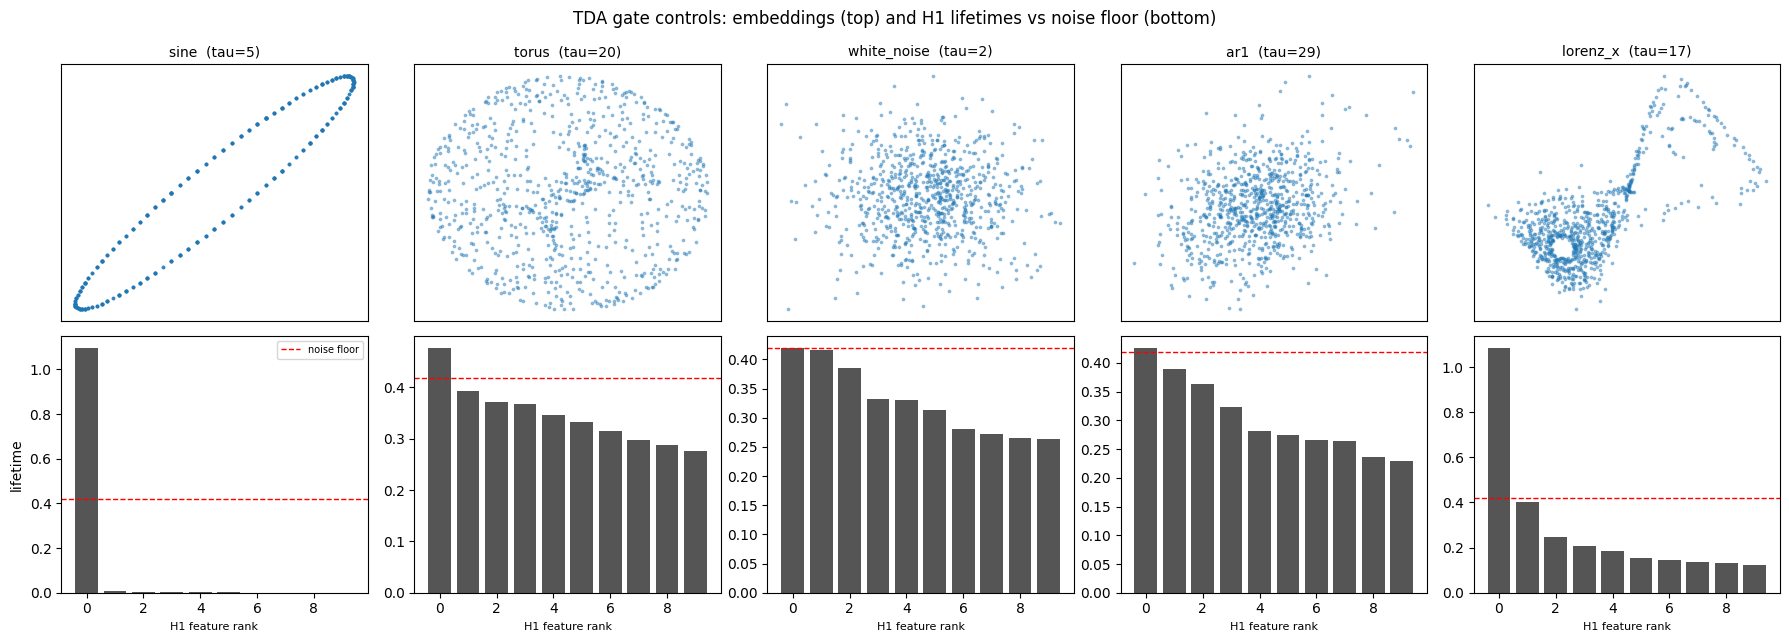

Saved tda_gate_visual.png


In [11]:
import matplotlib.pyplot as plt

show = ['sine', 'torus', 'white_noise', 'ar1', 'lorenz_x']
fig, axes = plt.subplots(2, 5, figsize=(18, 6.5))
for j, k in enumerate(show):
    r = results[k]
    ax = axes[0, j]
    ax.scatter(r['cloud'][:, 0], r['cloud'][:, 1], s=3, alpha=0.4)
    ax.set_title(f"{k}  (tau={r['tau']})", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    ax = axes[1, j]
    lt = r['lifetimes'][:10]
    ax.bar(range(len(lt)), lt, color='#555')
    ax.axhline(results['white_noise']['top1'], color='r', ls='--', lw=1, label='noise floor')
    ax.set_xlabel('H1 feature rank', fontsize=8)
    if j == 0:
        ax.set_ylabel('lifetime'); ax.legend(fontsize=7)
plt.suptitle('TDA gate controls: embeddings (top) and H1 lifetimes vs noise floor (bottom)')
plt.tight_layout()
plt.savefig('tda_gate_visual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved tda_gate_visual.png")

## Failure playbooks (only if a hard gate failed)

**Gate A fails (sine has no dominant loop).** Almost certainly tau
selection. Inspect the MI curve for the sine: if
`mutual_information_tau` hit its fallback (tau=1), the embedding
degenerates to a near-line. Fix: plot MI vs lag, consider
autocorrelation-first-zero as a fallback instead of tau=1. This failure
would also affect strongly periodic Weather channels — do not touch real
data until fixed.

**Gate C fails (Lorenz shows nothing above floor).** Pipeline-level
problem (embedding, subsampling density, or ripser config), since the
pilot run found dominant Lorenz loops. Check ripser version matches the
pilot environment; check the 800-point subsample visually covers the
attractor.

**Gate D or E fails (noise shows a dominant loop).** The pipeline
over-reads smooth/noisy data — the most dangerous failure for Weather.
Do NOT interpret any real-data loop as structure until a surrogate-based
significance test is added (per channel: 20 phase-randomised surrogates,
feature is significant only if its lifetime exceeds the 95th percentile
of surrogate max-lifetimes). This addition would then apply to the
real-data notebook too.

**Gate F fails (seed instability).** Increase `n_points` (e.g. 1200) in
BOTH this notebook and the real-data notebook, rerun gates.

**After all hard gates pass:** run `tda_persistent_homology_notebook`
on real Weather / ETTh1 / ETTh2 / Lorenz with no parameter changes, and
report per-dataset (max_pers, total_pers, n_features) medians with IQRs.
Interpretation remains correlational either way (see that notebook's
Cell 8 checklist).